In [14]:
!pip install scikit-image

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure

In [16]:
image_path = "ferrari_f1_bolid.png"

✅ TASK 1 – Histogram Equalization (Grayscale)


/tmp/ipython-input-1149775212.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray_image.ravel(), 256, [0,256])
/tmp/ipython-input-1149775212.py:24: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized_gray.ravel(), 256, [0,256])


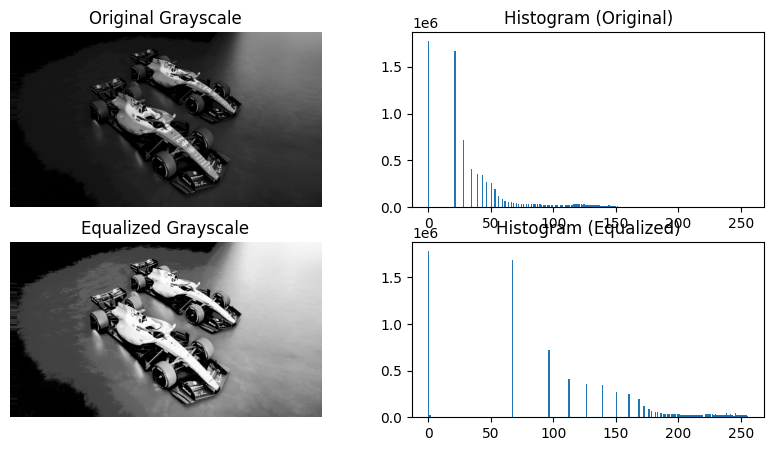

In [20]:
# Read as grayscale
gray_image = cv2.imread(os.path.join("sample_data", image_path), cv2.IMREAD_GRAYSCALE)

# Apply equalization
equalized_gray = cv2.equalizeHist(gray_image)

plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(gray_image, cmap='gray')
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(2,2,2)
plt.hist(gray_image.ravel(), 256, [0,256])
plt.title("Histogram (Original)")

plt.subplot(2,2,3)
plt.imshow(equalized_gray, cmap='gray')
plt.title("Equalized Grayscale")
plt.axis("off")

plt.subplot(2,2,4)
plt.hist(equalized_gray.ravel(), 256, [0,256])
plt.title("Histogram (Equalized)")

plt.show()

✅ TASK 2 – Color Histogram Equalization

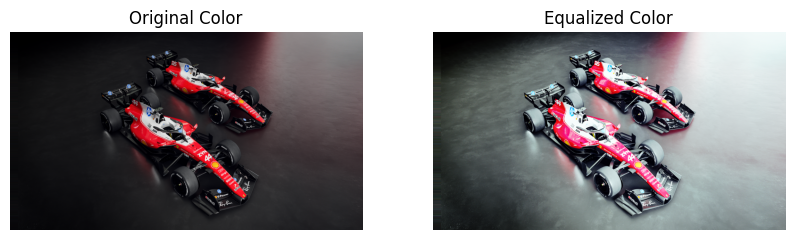

In [23]:
# Read as color
color_image = cv2.imread(os.path.join("sample_data", image_path))

# Split channels
b, g, r = cv2.split(color_image)

# Equalize each channel
eq_b = cv2.equalizeHist(b)
eq_g = cv2.equalizeHist(g)
eq_r = cv2.equalizeHist(r)

# Merge back
equalized_color = cv2.merge([eq_b, eq_g, eq_r])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.title("Original Color")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(equalized_color, cv2.COLOR_BGR2RGB))
plt.title("Equalized Color")
plt.axis("off")

plt.show()

✅ TASK 3 – Histogram Matching

/tmp/ipython-input-221940457.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray_image.ravel(),256,[0,256])
/tmp/ipython-input-221940457.py:24: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(bright_target.ravel(),256,[0,256])
/tmp/ipython-input-221940457.py:33: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(matched_image.ravel(),256,[0,256])


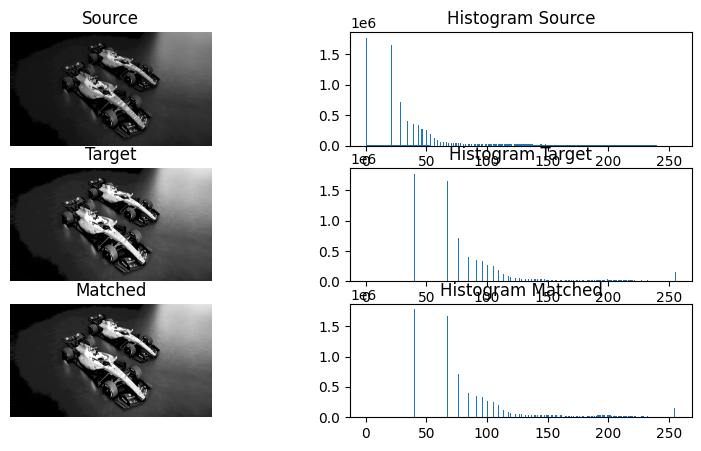

In [24]:
# Create artificial brighter target
bright_target = cv2.convertScaleAbs(gray_image, alpha=1.3, beta=40)

# Match histogram
matched_image = exposure.match_histograms(gray_image, bright_target)

plt.figure(figsize=(15,5))

plt.subplot(3,3,1)
plt.imshow(gray_image, cmap='gray')
plt.title("Source")
plt.axis("off")

plt.subplot(3,3,2)
plt.hist(gray_image.ravel(),256,[0,256])
plt.title("Histogram Source")

plt.subplot(3,3,4)
plt.imshow(bright_target, cmap='gray')
plt.title("Target")
plt.axis("off")

plt.subplot(3,3,5)
plt.hist(bright_target.ravel(),256,[0,256])
plt.title("Histogram Target")

plt.subplot(3,3,7)
plt.imshow(matched_image, cmap='gray')
plt.title("Matched")
plt.axis("off")

plt.subplot(3,3,8)
plt.hist(matched_image.ravel(),256,[0,256])
plt.title("Histogram Matched")

plt.show()

In [ ]:
✅ TASK 4 – Equalization + Matching

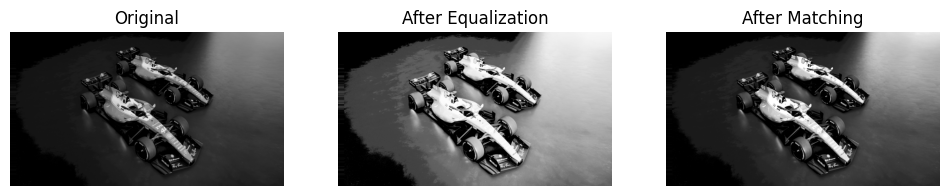

In [25]:
# Step 1: Equalize
equalized_first = cv2.equalizeHist(gray_image)

# Step 2: Match to bright target
final_image = exposure.match_histograms(equalized_first, bright_target)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(gray_image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(equalized_first, cmap='gray')
plt.title("After Equalization")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(final_image, cmap='gray')
plt.title("After Matching")
plt.axis("off")

plt.show()

# **REPORT FOR ALL TASK**

Task 1 – Histogram Equalization (Grayscale)

Histogram equalization was applied to the grayscale version of the Ferrari F1 image.
Before equalization, the histogram showed that pixel intensities were concentrated in a limited range, resulting in lower contrast.

After applying histogram equalization, the intensity values were redistributed more evenly across the full range (0–255).
This improved the overall contrast of the image and made details more visible.

Histogram equalization improves contrast especially in poorly lit images by stretching intensity distribution.

Task 2 – Histogram Equalization (Color Image)

Histogram equalization was applied separately to the Red, Green, and Blue channels.

After equalization, the image appeared more contrast-enhanced.
However, applying equalization to each channel independently may slightly alter the color balance of the image.

This happens because each channel is processed separately, which can change the relationship between colors.

Task 3 – Histogram Matching

Histogram matching was performed by transforming the histogram of the source image to match the histogram of a brighter target image.

After matching, the brightness and contrast of the source image became similar to the target image.
The histogram of the matched image closely resembled the target histogram.

Histogram matching is useful when we want two images to have similar brightness distribution.

Task 4 – Equalization Followed by Matching

First, histogram equalization improved the contrast of the source image.
Then, histogram matching adjusted the brightness distribution to match the target image.

This two-step process produced an image with both enhanced contrast and controlled brightness.